In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.shape

(10841, 13)

In [ ]:
df.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(483)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isna().sum() / len(df) * 100

App                0.000000
Category           0.000000
Rating            14.143657
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009654
Price              0.000000
Content Rating     0.009654
Genres             0.000000
Last Updated       0.000000
Current Ver        0.077235
Android Ver        0.028963
dtype: float64

In [ ]:
df['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        nan,  4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,
        3. ,  1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,
        1.8,  2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

In [ ]:
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,  3. ,
        1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,  1.8,
        2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

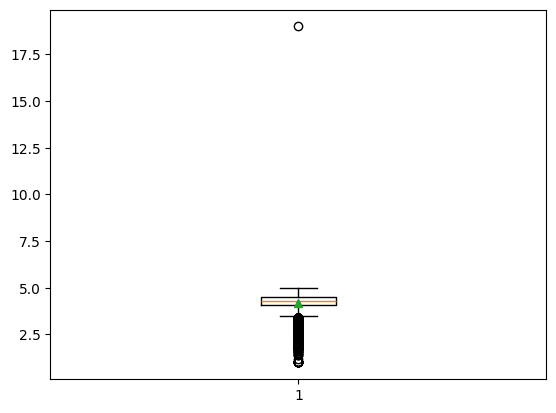

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Rating'],showbox=True,showmeans=True)
plt.show()

In [ ]:
df = df[df['Rating'] <= 5]

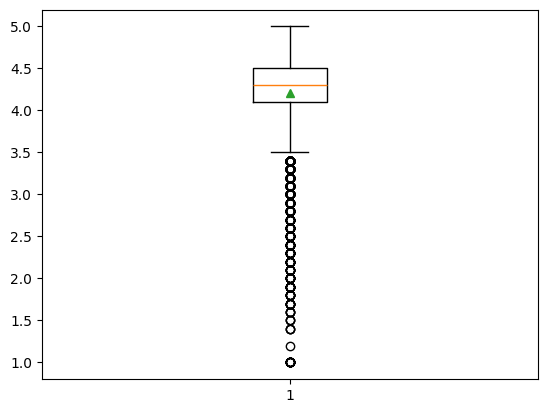

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Rating'],showbox=True,showmeans=True)
plt.show()

In [ ]:
df['Rating'].unique()

array([4.1, 3.9, 4.7, 4.5, 4.3, 4.4, 3.8, 4.2, 4.6, 3.2, 4. , 4.8, 4.9,
       3.6, 3.7, 3.3, 3.4, 3.5, 3.1, 5. , 2.6, 3. , 1.9, 2.5, 2.8, 2.7,
       1. , 2.9, 2.3, 2.2, 1.7, 2. , 1.8, 2.4, 1.6, 2.1, 1.4, 1.5, 1.2])

In [ ]:
df['Reviews'].isna().sum()

np.int64(0)

In [ ]:
df['Reviews'].max()

'9992'

In [ ]:
df['Reviews'].min()

'0'

In [ ]:
df['Size'].unique()

# for i in df['Size']:
#     if i.endswith('M') or i.endswith('m'):
#         print(i)

df['Size'].dtype
df['Size'].head()

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
Name: Size, dtype: str

In [ ]:
def convert_size(x):
    if isinstance(x,float):
        return x
    elif 'M' in x:
        return float(x.replace('M',''))
    elif 'k' in x:
        return float(x.replace('k','')) / 1000
    elif 'G' in x:
        return float(x.replace('G','')) * 1000

In [ ]:
df['Size'] = df['Size'].apply(convert_size)

In [ ]:
df['Size'] = df['Size'].round(2)
df['Size'].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [ ]:
df['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [ ]:
df['Installs'] = df['Installs'].str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)
df['Installs'] = df['Installs'].astype(int)

In [ ]:
df['Installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [ ]:
df[df['Type'].isna()]
df.isna().sum() / len(df) * 100

df[df['Size'].isna()]

df['Size'].head(3)

0    19.0
1    14.0
2     8.7
Name: Size, dtype: float64

In [ ]:
df['Size'] = df['Size'].fillna(df['Size'].median())

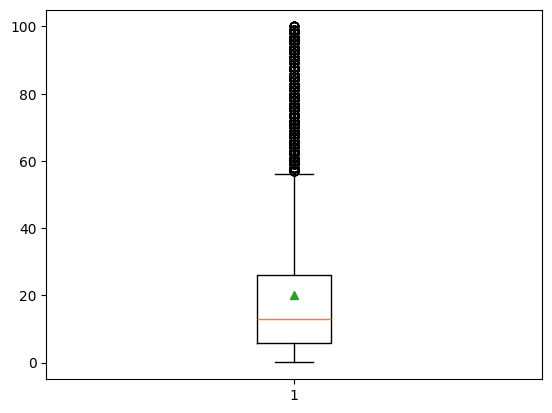

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Size'],showbox=True,showmeans=True)
plt.show()

In [ ]:
df.isna().sum() / len(df) * 100

App               0.000000
Category          0.000000
Rating            0.000000
Reviews           0.000000
Size              0.000000
Installs          0.000000
Type              0.009655
Price             0.000000
Content Rating    0.000000
Genres            0.000000
Last Updated      0.000000
Current Ver       0.077242
Android Ver       0.019311
dtype: float64

In [ ]:
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

In [ ]:
df['Type'].unique()

<StringArray>
['Free', 'Paid']
Length: 2, dtype: str

In [ ]:
df.isna().sum() / len(df) * 100

App               0.000000
Category          0.000000
Rating            0.000000
Reviews           0.000000
Size              0.000000
Installs          0.000000
Type              0.000000
Price             0.000000
Content Rating    0.000000
Genres            0.000000
Last Updated      0.000000
Current Ver       0.077242
Android Ver       0.019311
dtype: float64

In [ ]:
df['Current Ver'].unique()

<StringArray>
[             '1.0.0',              '2.0.0',              '1.2.4',
 'Varies with device',                '1.1',                '1.0',
           '6.1.61.1',              '2.9.2',                '2.8',
              '1.0.4',
 ...
           '3.20.001',             '1.3.81',               '1.74',
            '1.9.734',               '1.72',               '6.04',
            '1.5.447',         '1.0.612928',              '0.3.4',
          '2.0.148.0']
Length: 2832, dtype: str

In [ ]:
import numpy as np

df['Current Ver'] = df['Current Ver'].replace('Varies with device',np.nan)


In [ ]:
df['Current Ver'].unique()

<StringArray>
[     '1.0.0',      '2.0.0',      '1.2.4',          nan,        '1.1',
        '1.0',   '6.1.61.1',      '2.9.2',        '2.8',      '1.0.4',
 ...
   '3.20.001',     '1.3.81',       '1.74',    '1.9.734',       '1.72',
       '6.04',    '1.5.447', '1.0.612928',      '0.3.4',  '2.0.148.0']
Length: 2831, dtype: str

In [ ]:
df['Current Ver'] = df['Current Ver'].fillna(df['Current Ver'].mode()[0])

In [ ]:
df.isna().sum() / len(df) * 100

App               0.000000
Category          0.000000
Rating            0.000000
Reviews           0.000000
Size              0.000000
Installs          0.000000
Type              0.000000
Price             0.000000
Content Rating    0.000000
Genres            0.000000
Last Updated      0.000000
Current Ver       0.000000
Android Ver       0.019311
dtype: float64

In [ ]:
df['Android Ver'].unique()

<StringArray>
[      '4.0.3 and up',         '4.2 and up',         '4.4 and up',
         '2.3 and up',         '3.0 and up',         '4.1 and up',
         '4.0 and up',       '2.3.3 and up', 'Varies with device',
         '2.2 and up',         '5.0 and up',         '6.0 and up',
         '1.6 and up',         '1.5 and up',         '2.1 and up',
         '7.0 and up',         '5.1 and up',         '4.3 and up',
      '4.0.3 - 7.1.1',         '2.0 and up',         '3.2 and up',
        '4.4W and up',         '7.1 and up',        '7.0 - 7.1.1',
         '8.0 and up',          '5.0 - 8.0',         '3.1 and up',
       '2.0.1 and up',        '4.1 - 7.1.1',                  nan,
          '5.0 - 6.0',         '1.0 and up',        '2.2 - 7.1.1',
        '5.0 - 7.1.1']
Length: 34, dtype: str

In [ ]:
import numpy as np

df['Android Ver'] = df['Android Ver'].replace('Varies with device',np.nan)


In [ ]:
df['Android Ver'].isna().sum()

np.int64(1223)

In [ ]:
df['Android Ver'] = df['Android Ver'].fillna(df['Android Ver'].mode()[0])

In [ ]:
df['Android Ver'].isna().sum()

np.int64(0)

In [ ]:
df.isna().sum() / len(df) * 100

App               0.0
Category          0.0
Rating            0.0
Reviews           0.0
Size              0.0
Installs          0.0
Type              0.0
Price             0.0
Content Rating    0.0
Genres            0.0
Last Updated      0.0
Current Ver       0.0
Android Ver       0.0
dtype: float64

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  str    
 1   Category        10357 non-null  str    
 2   Rating          10357 non-null  float64
 3   Reviews         10357 non-null  str    
 4   Size            10357 non-null  float64
 5   Installs        10357 non-null  int64  
 6   Type            10357 non-null  str    
 7   Price           10357 non-null  str    
 8   Content Rating  10357 non-null  str    
 9   Genres          10357 non-null  str    
 10  Last Updated    10357 non-null  str    
 11  Current Ver     10357 non-null  str    
 12  Android Ver     10357 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 1.1 MB


In [ ]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [ ]:
df['App'] = df['App'].str.strip()
df['Category'] = df['Category'].str.strip()
df['Content Rating'] = df['Content Rating'].str.strip()
df['Genres'] = df['Genres'].str.strip()
df['Android Ver'] = df['Android Ver'].str.strip()

In [ ]:
df['Content Rating'].unique()

<StringArray>
['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+',
 'Unrated']
Length: 6, dtype: str

In [ ]:
import numpy as np

df['Content Rating'] = df['Content Rating'].replace('Unrated',np.nan)

In [ ]:
df['Content Rating'] = df['Content Rating'].fillna(df['Content Rating'].mode()[0])

In [ ]:
df['Content Rating'].unique()

<StringArray>
['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+', 'Adults only 18+']
Length: 5, dtype: str

In [ ]:
df['Genres'].unique()

<StringArray>
[                   'Art & Design',       'Art & Design;Pretend Play',
         'Art & Design;Creativity', 'Art & Design;Action & Adventure',
                 'Auto & Vehicles',                          'Beauty',
               'Books & Reference',                        'Business',
                          'Comics',               'Comics;Creativity',
 ...
             'Lifestyle;Education',    'Books & Reference;Creativity',
     'Books & Reference;Education',                'Puzzle;Education',
          'Role Playing;Education',        'Role Playing;Brain Games',
              'Strategy;Education',             'Racing;Pretend Play',
        'Communication;Creativity',             'Strategy;Creativity']
Length: 119, dtype: str

In [ ]:
import re

pattern = ';'

for i in df['Genres']:
    if re.search(pattern,i):
        print(i)

Art & Design;Pretend Play
Art & Design;Creativity
Art & Design;Creativity
Art & Design;Action & Adventure
Art & Design;Creativity
Art & Design;Creativity
Art & Design;Creativity
Comics;Creativity
Education;Education
Education;Creativity
Education;Creativity
Education;Education
Education;Music & Video
Education;Education
Education;Creativity
Education;Action & Adventure
Education;Pretend Play
Education;Education
Education;Brain Games
Education;Brain Games
Education;Brain Games
Education;Education
Education;Education
Education;Education
Education;Education
Education;Education
Education;Education
Education;Pretend Play
Education;Education
Education;Pretend Play
Education;Pretend Play
Entertainment;Music & Video
Entertainment;Brain Games
Entertainment;Brain Games
Entertainment;Creativity
Entertainment;Music & Video
Entertainment;Music & Video
Entertainment;Music & Video
Entertainment;Music & Video
Entertainment;Music & Video
Entertainment;Music & Video
Lifestyle;Pretend Play
Adventure;Acti

In [ ]:
df['Genres'] = df['Genres'].str.split(';').str[0]

In [ ]:
df['Genres'].unique()

array(['Art & Design', 'Auto & Vehicles', 'Beauty', 'Books & Reference',
       'Business', 'Comics', 'Communication', 'Dating', 'Education',
       'Entertainment', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Adventure', 'Arcade', 'Casual', 'Card', 'Action',
       'Strategy', 'Puzzle', 'Sports', 'Music', 'Word', 'Racing',
       'Simulation', 'Board', 'Trivia', 'Role Playing', 'Educational',
       'Music & Audio', 'Video Players & Editors', 'Medical', 'Social',
       'Shopping', 'Photography', 'Travel & Local', 'Tools',
       'Personalization', 'Productivity', 'Parenting', 'Weather',
       'News & Magazines', 'Maps & Navigation', 'Casino'], dtype=object)

In [ ]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [ ]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,2018-06-08,1.0,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design,2018-06-20,1.1,4.4 and up


In [ ]:
df['Last Upadted Year'] = df['Last Updated'].dt.year
df['Last Updated Month'] = df['Last Updated'].dt.month
df['Last Updated Day'] = df['Last Updated'].dt.day

In [ ]:
df.drop(['Last Updated'],axis=1,inplace=True)

In [ ]:
df['Android Ver'].unique()

<StringArray>
[ '4.0.3 and up',    '4.2 and up',    '4.4 and up',    '2.3 and up',
    '3.0 and up',    '4.1 and up',    '4.0 and up',  '2.3.3 and up',
    '2.2 and up',    '5.0 and up',    '6.0 and up',    '1.6 and up',
    '1.5 and up',    '2.1 and up',    '7.0 and up',    '5.1 and up',
    '4.3 and up', '4.0.3 - 7.1.1',    '2.0 and up',    '3.2 and up',
   '4.4W and up',    '7.1 and up',   '7.0 - 7.1.1',    '8.0 and up',
     '5.0 - 8.0',    '3.1 and up',  '2.0.1 and up',   '4.1 - 7.1.1',
     '5.0 - 6.0',    '1.0 and up',   '2.2 - 7.1.1',   '5.0 - 7.1.1']
Length: 32, dtype: str

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10357 non-null  str    
 1   Category            10357 non-null  str    
 2   Rating              10357 non-null  float64
 3   Reviews             10357 non-null  str    
 4   Size                10357 non-null  float64
 5   Installs            10357 non-null  int64  
 6   Type                10357 non-null  str    
 7   Price               10357 non-null  str    
 8   Content Rating      10357 non-null  str    
 9   Genres              10357 non-null  object 
 10  Current Ver         10357 non-null  str    
 11  Android Ver         10357 non-null  str    
 12  Last Upadted Year   10357 non-null  int32  
 13  Last Updated Month  10357 non-null  int32  
 14  Last Updated Day    10357 non-null  int32  
dtypes: float64(2), int32(3), int64(1), object(1), str(8)
memory usage: 1.

In [ ]:
df['Genres'] = df['Genres'].astype(str)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10357 non-null  str    
 1   Category            10357 non-null  str    
 2   Rating              10357 non-null  float64
 3   Reviews             10357 non-null  str    
 4   Size                10357 non-null  float64
 5   Installs            10357 non-null  int64  
 6   Type                10357 non-null  str    
 7   Price               10357 non-null  str    
 8   Content Rating      10357 non-null  str    
 9   Genres              10357 non-null  str    
 10  Current Ver         10357 non-null  str    
 11  Android Ver         10357 non-null  str    
 12  Last Upadted Year   10357 non-null  int32  
 13  Last Updated Month  10357 non-null  int32  
 14  Last Updated Day    10357 non-null  int32  
dtypes: float64(2), int32(3), int64(1), str(9)
memory usage: 1.1 MB


In [ ]:
df['Reviews'].unique()

import re

for i in df['Reviews']:
    if not re.match(r'^\d+$', str(i)):
        print(i)


In [ ]:
df['Reviews'] = df['Reviews'].astype(int)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10357 non-null  str    
 1   Category            10357 non-null  str    
 2   Rating              10357 non-null  float64
 3   Reviews             10357 non-null  int64  
 4   Size                10357 non-null  float64
 5   Installs            10357 non-null  int64  
 6   Type                10357 non-null  str    
 7   Price               10357 non-null  str    
 8   Content Rating      10357 non-null  str    
 9   Genres              10357 non-null  str    
 10  Current Ver         10357 non-null  str    
 11  Android Ver         10357 non-null  str    
 12  Last Upadted Year   10357 non-null  int32  
 13  Last Updated Month  10357 non-null  int32  
 14  Last Updated Day    10357 non-null  int32  
dtypes: float64(2), int32(3), int64(2), str(8)
memory usage: 1.1 MB


In [ ]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Last Upadted Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design,2.0.0,4.0.3 and up,2018,1,15


In [ ]:
df['Price'] = df['Price'].str.replace('$','', regex=False)
df['Price'].unique()

<StringArray>
[     '0',   '4.99',   '3.99',   '6.99',   '1.49',   '2.99',   '7.99',
   '5.99',   '3.49',   '1.99',   '9.99',   '7.49',   '0.99',   '9.00',
   '5.49',  '10.00',  '24.99',  '11.99',  '79.99',  '16.99',  '14.99',
   '1.00',  '29.99',  '12.99',   '2.49',  '10.99',   '1.50',  '19.99',
  '15.99',  '33.99',  '74.99',  '39.99',   '3.95',   '4.49',   '1.70',
   '8.99',   '2.00',   '3.88',  '25.99', '399.99',  '17.99', '400.00',
   '3.02',   '1.76',   '4.84',   '4.77',   '1.61',   '2.50',   '1.59',
   '6.49',   '1.29',   '5.00',  '13.99', '299.99', '379.99',  '37.99',
  '18.99', '389.99',  '19.90',   '8.49',   '1.75',  '14.00',   '4.85',
  '46.99', '109.99', '154.99',   '3.08',   '2.59',   '4.80',   '1.96',
  '19.40',   '3.90',   '4.59',  '15.46',   '3.04',   '4.29',   '2.60',
   '3.28',   '4.60',  '28.99',   '2.95',   '2.90',   '1.97', '200.00',
  '89.99',   '2.56',  '30.99',   '3.61', '394.99',   '1.26',   '1.20',
   '1.04']
Length: 92, dtype: str

In [ ]:
df['Price'] = df['Price'].astype(float)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   App                 10357 non-null  str    
 1   Category            10357 non-null  str    
 2   Rating              10357 non-null  float64
 3   Reviews             10357 non-null  int64  
 4   Size                10357 non-null  float64
 5   Installs            10357 non-null  int64  
 6   Type                10357 non-null  str    
 7   Price               10357 non-null  float64
 8   Content Rating      10357 non-null  str    
 9   Genres              10357 non-null  str    
 10  Current Ver         10357 non-null  str    
 11  Android Ver         10357 non-null  str    
 12  Last Upadted Year   10357 non-null  int32  
 13  Last Updated Month  10357 non-null  int32  
 14  Last Updated Day    10357 non-null  int32  
dtypes: float64(3), int32(3), int64(2), str(7)
memory usage: 1.1 MB


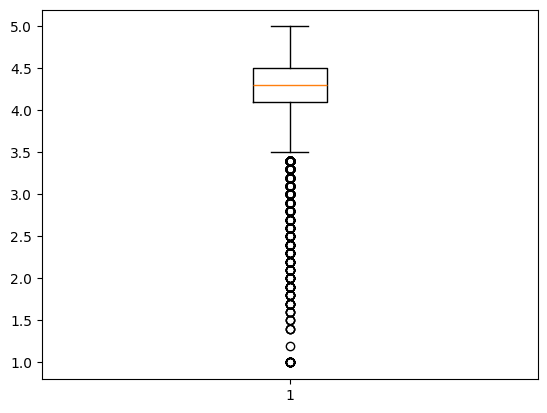

In [ ]:
plt.boxplot(df['Rating'])
plt.show()

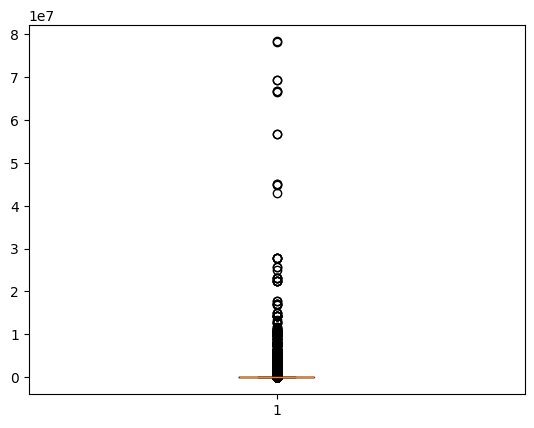

In [ ]:
plt.boxplot(df['Reviews'])
plt.show()

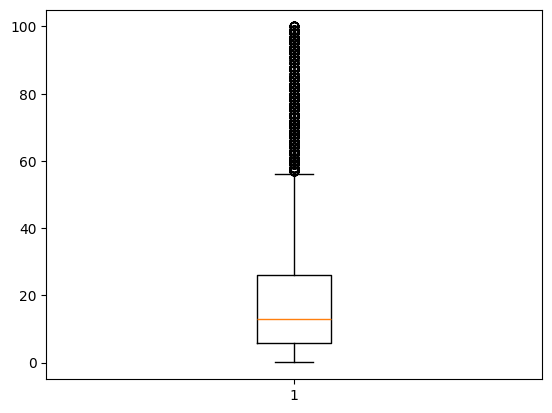

In [ ]:
plt.boxplot(df['Size'])
plt.show()

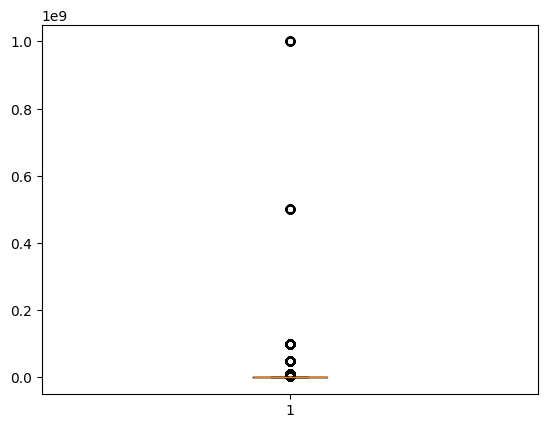

In [ ]:
plt.boxplot(df['Installs'])
plt.show()

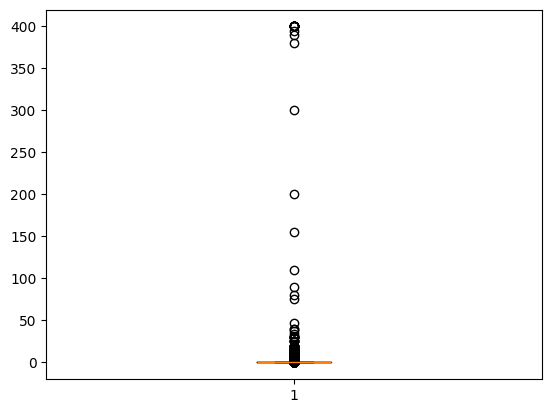

In [ ]:
plt.boxplot(df['Price'])
plt.show()

In [ ]:
def func(p):
    if p == 0:
        return 'Free'
    elif p <= 5:
        return 'Low Price'
    elif p <= 50:
        return 'Moderate'
    elif p <= 200:
        return 'High Price'
    else:
        return 'Luxury'

In [ ]:
df['Price Category'] = df['Price'].apply(func)

In [ ]:
col = df.pop('Price Category')
df.insert(8,'Price Category',col)

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Price Category,Content Rating,Genres,Current Ver,Android Ver,Last Upadted Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Free,Everyone,Art & Design,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Free,Everyone,Art & Design,2.0.0,4.0.3 and up,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Free,Everyone,Art & Design,1.2.4,4.0.3 and up,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Free,Teen,Art & Design,1.0,4.2 and up,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Free,Everyone,Art & Design,1.1,4.4 and up,2018,6,20


In [ ]:
df.to_csv('CleanedPlaystoreData.csv')

In [ ]:
df.rename(columns={'Last Upadted Year':'Last Updated Year'},inplace=True)

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Price Category,Content Rating,Genres,Current Ver,Android Ver,Last Updated Year,Last Updated Month,Last Updated Day
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Free,Everyone,Art & Design,1.0.0,4.0.3 and up,2018,1,7
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Free,Everyone,Art & Design,2.0.0,4.0.3 and up,2018,1,15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Free,Everyone,Art & Design,1.2.4,4.0.3 and up,2018,8,1
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Free,Teen,Art & Design,1.0,4.2 and up,2018,6,8
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Free,Everyone,Art & Design,1.1,4.4 and up,2018,6,20


In [ ]:
df.columns = df.columns.str.replace(' ','_')

In [ ]:
df.to_csv('CleanedPlaystoreData.csv',index=False)